# NeuralTuner TRL Training Notebook (Mac-first)

This notebook is for training and evaluation only. Inference-only logic lives in `inference.py`.

Model default: `Qwen/Qwen2.5-1.5B-Instruct`


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from server.neural_tuner_env_environment import NeuralTunerEnvironment
from models import NeuralTunerAction


In [ ]:
# Optional: set token in shell before launching Jupyter, or via .env.local
# Example in terminal: export HF_TOKEN=your_token_here
import os
# os.environ["HF_TOKEN"] = ""
print("HF_TOKEN loaded:", bool(os.getenv("HF_TOKEN")))

HF_TOKEN loaded: False


## 1) Environment smoke test
Validate reset/step/state before training.

In [3]:
env = NeuralTunerEnvironment()
reset_obs = env.reset(model_id="inception_v3", difficulty="medium", seed=42)
print(reset_obs.output[:800])

bench = env.step(NeuralTunerAction(action_type="benchmark"))
print(bench.output)
print(env.state)


NEURAL TUNER  —  INCEPTION V3
Model:       Inception V3  (47.0M params)
Description: Google Inception V3 image classifier (47M params).
Difficulty:  MEDIUM

BASELINE
  Latency: 175.1 ms
  Memory:  186.1 MB

SNAPDRAGON HTP CONSTRAINTS
  Latency budget:  78.8 ms
  Memory budget:   83.7 MB
  Min accuracy:    0.9

SCENARIO
  Tight latency target for a flagship Snapdragon mobile deployment. Must use INT4 selectively while keeping classifier accuracy intact.

LAYERS (10 total)
  Layer ID                     Type                       Latency    Memory  Sensitivity  Pruning
  ----------------------------------------------------------------------------------------------
BENCHMARK 1/5
  Latency:   175.10 ms  (budget 78.8 ms)  [FAIL]  ↓0.0%
  Memory:    186.10 MB  (budget 83.7 MB)  [FAIL]
  Accuracy: 1.0000  (min 0.9)  [PASS]
  Projected reward: 0.2000
  All constraints met: NO
  Benchmarks remaining: 4
episode_id='9ffc9cac-1663-46a4-aa3e-6b26b647d389' step_count=1 model_id='inception_v3' diffic

## 2) Baseline data collection
Collect random/untrained policy episodes for comparison.

In [4]:
from rollout_eval import run_random_episode, run_baseline_episode, run_heuristic_episode
import statistics

env = NeuralTunerEnvironment()

# True pre-training baseline: random dtype assignment, no profiling
random_rewards = []
for seed in range(20):
    m = run_random_episode(env, "inception_v3", "medium", seed=seed)
    random_rewards.append(m.final_reward)

random_mean = statistics.mean(random_rewards)
random_std = statistics.stdev(random_rewards)

# Reference upper ceiling (deterministic oracle)
oracle = run_baseline_episode(env, "inception_v3", "medium")

print(f"Pre-training (random policy, n=20):  mean={random_mean:.4f}  std={random_std:.4f}  min={min(random_rewards):.4f}  max={max(random_rewards):.4f}")
print(f"Oracle ceiling (INT4/INT8 pattern):   reward={oracle.final_reward:.4f}  constraints_met={oracle.constraints_met}")
print(f"")
print(f"Improvement headroom: {oracle.final_reward - random_mean:.4f} ({(oracle.final_reward/random_mean - 1)*100:.1f}% above random)")
print(f"GRPO target: bring random {random_mean:.3f} closer to {oracle.final_reward:.3f}")


Pre-training (random policy, n=20):  mean=0.4650  std=0.1883  min=0.2649  max=0.7668
Oracle ceiling (INT4/INT8 pattern):   reward=0.7860  constraints_met=True

Improvement headroom: 0.3210 (69.0% above random)
GRPO target: bring random 0.465 closer to 0.786


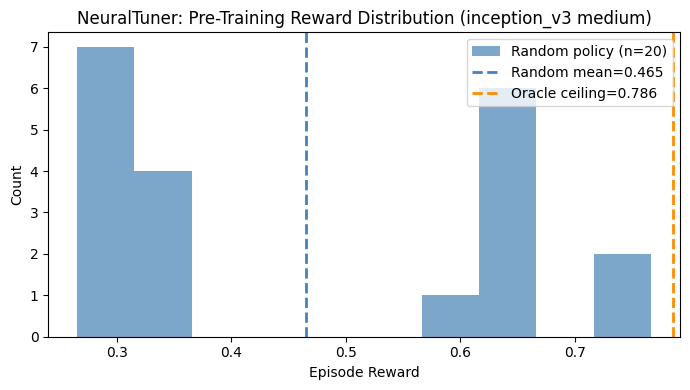

Saved: artifacts/plots/pre_training_reward_distribution.png


In [5]:
# Pre-training reward distribution — shows what the model starts from
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(random_rewards, bins=10, color="steelblue", alpha=0.7, label="Random policy (n=20)")
ax.axvline(random_mean, color="steelblue", linestyle="--", lw=2, label=f"Random mean={random_mean:.3f}")
ax.axvline(oracle.final_reward, color="darkorange", linestyle="--", lw=2, label=f"Oracle ceiling={oracle.final_reward:.3f}")
ax.set_xlabel("Episode Reward")
ax.set_ylabel("Count")
ax.set_title("NeuralTuner: Pre-Training Reward Distribution (inception_v3 medium)")
ax.legend()
plt.tight_layout()
plot_dir = Path("artifacts/plots")
plot_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_dir / "pre_training_reward_distribution.png", dpi=150)
plt.show()
print(f"Saved: artifacts/plots/pre_training_reward_distribution.png")


## 3) Qwen + TRL OpenEnv setup (tiny run)
This section follows the TRL OpenEnv notebook pattern (`environment_factory`) but uses the local NeuralTuner environment and low-cost defaults for first-run debugging.

In [6]:
from huggingface_hub import snapshot_download

HF_TOKEN = os.getenv("HF_TOKEN")
LOCAL_MODEL_DIR = Path(".hf_cache/Qwen--Qwen2.5-1.5B-Instruct").resolve()
LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)


def _has_local_model_tensors(model_dir: Path) -> bool:
    has_config = (model_dir / "config.json").exists()
    has_tokenizer = (model_dir / "tokenizer.json").exists() or (model_dir / "tokenizer_config.json").exists()
    has_weights = any(model_dir.glob("*.safetensors")) or any(model_dir.glob("*.bin"))
    return has_config and has_tokenizer and has_weights


if _has_local_model_tensors(LOCAL_MODEL_DIR):
    print(f"Using cached model (no download): {LOCAL_MODEL_DIR}")
else:
    print(f"Cache incomplete. Downloading model to: {LOCAL_MODEL_DIR}")
    snapshot_download(
        repo_id="Qwen/Qwen2.5-1.5B-Instruct",
        local_dir=str(LOCAL_MODEL_DIR),
        token=HF_TOKEN,
    )

MODEL_NAME = str(LOCAL_MODEL_DIR)
print(f"MODEL_NAME set to local path: {MODEL_NAME}")

Using cached model (no download): /Users/altaf/code/round_2/.hf_cache/Qwen--Qwen2.5-1.5B-Instruct
MODEL_NAME set to local path: /Users/altaf/code/round_2/.hf_cache/Qwen--Qwen2.5-1.5B-Instruct


In [7]:
from dataclasses import asdict
from typing import Optional
from pathlib import Path
from datasets import Dataset
from peft import LoraConfig
from transformers import AutoTokenizer
from trl import GRPOConfig, GRPOTrainer
from trl.chat_template_utils import qwen3_chat_template, qwen3_schema


TARGET_LOCAL_MODEL_DIR = Path(globals().get("MODEL_NAME", ".hf_cache/Qwen--Qwen2.5-1.5B-Instruct")).resolve()
MODEL_NAME = str(TARGET_LOCAL_MODEL_DIR)
if not TARGET_LOCAL_MODEL_DIR.exists():
    raise FileNotFoundError(f"Expected local model cache missing: {TARGET_LOCAL_MODEL_DIR}")

OUTPUT_DIR = "outputs/neural_tuner_grpo_tiny_lora"
TRAIN_EPISODES = 16
NUM_EPOCHS = 1
SYSTEM_PROMPT = """You are a hardware optimization agent for NeuralTuner.
Use available tools to profile layers, apply quantization and pruning, benchmark, and submit.
Prioritize meeting latency, memory, and accuracy constraints while maximizing reward.
"""

# Qwen2.5 chat template is not auto-recognized by TRL tool-calling parser.
# Force a compatible template + explicit response schema to bypass auto-detection failures.
processing_class = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, local_files_only=True)
processing_class.chat_template = qwen3_chat_template
processing_class.response_schema = qwen3_schema

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)


class NeuralTunerOpenEnv:
    """OpenEnv wrapper compatible with TRL environment_factory."""

    scenario_schedule: list[dict] = []
    schedule_idx: int = 0

    def __init__(self):
        self._env = NeuralTunerEnvironment()
        self.reward = 0.0
        self.done = False

    def reset(self, **kwargs) -> str:
        scenario = None
        if kwargs.get("model_id") or kwargs.get("difficulty"):
            scenario = {
                "model_id": kwargs.get("model_id", "inception_v3"),
                "difficulty": kwargs.get("difficulty", "medium"),
            }
        elif self.scenario_schedule:
            scenario = self.scenario_schedule[self.schedule_idx % len(self.scenario_schedule)]
            NeuralTunerOpenEnv.schedule_idx += 1
        else:
            scenario = {"model_id": "inception_v3", "difficulty": "medium"}

        obs = self._env.reset(
            difficulty=scenario["difficulty"],
            model_id=scenario["model_id"],
            seed=kwargs.get("seed", 42),
        )
        self.reward = 0.0
        self.done = False
        return obs.output

    def _step(self, action_type: str, layer_id: Optional[str] = None, dtype: Optional[str] = None, sparsity: Optional[str] = None) -> str:
        result = self._env.step(
            NeuralTunerAction(action_type=action_type, layer_id=layer_id, dtype=dtype, sparsity=sparsity)
        )
        self.reward = float(result.reward)
        self.done = bool(result.done)
        return result.output

    def profile_layer(self, layer_id: str) -> str:
        """Reveal sensitivity and hardware risk for a specific layer.

        Args:
            layer_id: Layer identifier from the environment layer table.

        Returns:
            Text report containing sensitivity score and optimization hints.
        """
        return self._step("profile_layer", layer_id=layer_id)

    def quantize_layer(self, layer_id: str, dtype: str) -> str:
        """Apply a quantization dtype to one layer.

        Args:
            layer_id: Layer identifier from the environment layer table.
            dtype: Quantization target, one of FP32, FP16, INT8, INT4.

        Returns:
            Text summary of the quantization change.
        """
        return self._step("quantize_layer", layer_id=layer_id, dtype=dtype)

    def prune_layer(self, layer_id: str, sparsity: str) -> str:
        """Apply structured pruning to one layer for Snapdragon sparse-acceleration.

        Pruning removes channels/filters, reducing compute and memory. The Snapdragon
        HTP has dedicated hardware for sparse workloads — combine with quantization
        for maximum compression. Profile first to gauge accuracy risk.

        Args:
            layer_id: Layer identifier from the environment layer table.
            sparsity: Pruning level — LOW (25% removed), MEDIUM (50%), or HIGH (75%).

        Returns:
            Text summary of the pruning change and expected impact.
        """
        return self._step("prune_layer", layer_id=layer_id, sparsity=sparsity)

    def revert_layer(self, layer_id: str) -> str:
        """Reset one layer back to FP32 with no pruning.

        Args:
            layer_id: Layer identifier from the environment layer table.

        Returns:
            Text summary confirming the revert action.
        """
        return self._step("revert_layer", layer_id=layer_id)

    def benchmark(self) -> str:
        """Run hardware simulation for the current quantization and pruning plan.

        Returns:
            Benchmark report with latency, memory, accuracy, and projected reward.
        """
        return self._step("benchmark")

    def submit(self) -> str:
        """Finalize the episode and compute the final reward.

        Returns:
            Final submission summary including constraint pass/fail and reward.
        """
        return self._step("submit")


def reward_func(environments, **kwargs) -> list[float]:
    rewards = []
    for env in environments:
        if not env.done:
            # Auto-submit if model ran out of tokens without calling submit().
            # Without this, reward stays 0 and GRPO gets zero gradient signal.
            env.submit()
        rewards.append(float(env.reward))
    return rewards


MOCK_DATA_PATH = Path("data/mock_data/neural_tuner_train_scenarios.jsonl")


def _load_mock_scenarios(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(f"Mock training data not found: {path}")
    rows = []
    with path.open() as fp:
        for line in fp:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    if not rows:
        raise ValueError(f"No scenarios found in {path}")
    return rows


def _build_prompt_row(scenario: dict) -> list[dict]:
    scenario_text = (
        f"Scenario ID: {scenario['id']}\n"
        f"Model: {scenario['model_id']}\n"
        f"Difficulty: {scenario['difficulty']}\n"
        f"Hint: {scenario['scenario_hint']}\n"
        f"Target behavior: {scenario['target_behavior']}\n"
        f"Notes: {scenario['notes']}\n"
    )
    return [{"role": "user", "content": SYSTEM_PROMPT + "\n\n" + scenario_text}]


mock_scenarios = _load_mock_scenarios(MOCK_DATA_PATH)
expanded = (mock_scenarios * ((TRAIN_EPISODES + len(mock_scenarios) - 1) // len(mock_scenarios)))[:TRAIN_EPISODES]

# Align environment resets with mock training prompts.
NeuralTunerOpenEnv.scenario_schedule = expanded
NeuralTunerOpenEnv.schedule_idx = 0

train_dataset = Dataset.from_dict(
    {
        "prompt": [_build_prompt_row(s) for s in expanded],
        "model_id": [s["model_id"] for s in expanded],
        "difficulty": [s["difficulty"] for s in expanded],
        "scenario_id": [s["id"] for s in expanded],
    }
)
print(f"dataset size: {len(train_dataset)} episodes")
print(f"model: {MODEL_NAME}")
print(f"mock source: {MOCK_DATA_PATH}")
print("sample prompt:")
print(train_dataset[0]["prompt"][0]["content"][:450])


dataset size: 16 episodes
model: /Users/altaf/code/round_2/.hf_cache/Qwen--Qwen2.5-1.5B-Instruct
mock source: data/mock_data/neural_tuner_train_scenarios.jsonl
sample prompt:
You are a hardware optimization agent for NeuralTuner.
Use available tools to profile layers, apply quantization and pruning, benchmark, and submit.
Prioritize meeting latency, memory, and accuracy constraints while maximizing reward.


Scenario ID: s1
Model: inception_v3
Difficulty: easy
Hint: Start by profiling the largest inception blocks and avoid quantizing classifier aggressively.
Target behavior: profile_first_then_quantize
Notes: Prefer I


## 4) Save baseline + tiny training dataset
This saves baseline metrics and prompt data so you can trace what was used for training.

In [8]:
from rollout_eval import run_baseline_episode, run_heuristic_episode

artifacts_dir = Path("artifacts/training")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Baseline before training
baseline_env = NeuralTunerEnvironment()
baseline_metrics = run_baseline_episode(baseline_env, "inception_v3", "medium")
heuristic_metrics = run_heuristic_episode(baseline_env, "inception_v3", "medium")

baseline_path = artifacts_dir / "baseline_metrics.jsonl"
with baseline_path.open("w") as fp:
    fp.write(json.dumps(asdict(baseline_metrics)) + "\n")
    fp.write(json.dumps(asdict(heuristic_metrics)) + "\n")

# Persist tiny training prompts
prompts_path = artifacts_dir / "train_prompts.jsonl"
with prompts_path.open("w") as fp:
    for row in train_dataset:
        fp.write(json.dumps(row) + "\n")

print("Baseline metrics:")
print(asdict(baseline_metrics))
print(asdict(heuristic_metrics))
print(f"Saved baseline file: {baseline_path}")
print(f"Saved prompts file: {prompts_path}")


Baseline metrics:
{'policy': 'baseline', 'episode_index': 0, 'model_id': 'inception_v3', 'difficulty': 'medium', 'final_reward': 0.786, 'done': True, 'step_count': 10, 'benchmark_count': 1, 'latency_ms': 64.18, 'memory_mb': 40.01, 'accuracy_retention': 0.9663, 'constraints_met': True}
{'policy': 'heuristic', 'episode_index': 0, 'model_id': 'inception_v3', 'difficulty': 'medium', 'final_reward': 0.6428, 'done': True, 'step_count': 14, 'benchmark_count': 1, 'latency_ms': 93.77, 'memory_mb': 77.11, 'accuracy_retention': 0.9785, 'constraints_met': False}
Saved baseline file: artifacts/training/baseline_metrics.jsonl
Saved prompts file: artifacts/training/train_prompts.jsonl


## 5) Train tiny GRPO run, save checkpoint, print training results

In [ ]:
grpo_config = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    max_steps=20,
    learning_rate=1e-6,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    warmup_steps=2,
    max_completion_length=768,
    num_generations=4,
    generation_batch_size=4,
    temperature=1.0,
    top_p=1.0,
    generation_kwargs={"do_sample": False},
    gradient_checkpointing=True,
    torch_empty_cache_steps=1,
    logging_steps=1,
    save_steps=20,
    save_total_limit=1,
    report_to="none",
    use_cpu=True,
    bf16=False,
    fp16=False,
    use_vllm=False,
)

trainer = GRPOTrainer(
    model=MODEL_NAME,
    reward_funcs=reward_func,
    train_dataset=train_dataset,
    args=grpo_config,
    processing_class=processing_class,
    peft_config=peft_config,
    environment_factory=NeuralTunerOpenEnv,
)

trainer_stats = trainer.train()
trainer.save_model(OUTPUT_DIR)

metrics_path = Path("artifacts/training/train_metrics.json")
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text(json.dumps(trainer_stats.metrics, indent=2))

print("Training complete.")
print(f"Saved checkpoint: {OUTPUT_DIR}")
print(f"Saved metrics: {metrics_path}")
print("Key metrics:")
for key in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss"]:
    if key in trainer_stats.metrics:
        print(f"  {key}: {trainer_stats.metrics[key]}")

# Post-training comparison against the true pre-training random baseline from Section 2.
# random_mean, random_std, random_rewards, and oracle are computed in Section 2.
loss_logs = [x for x in trainer.state.log_history if "loss" in x]
reward_logs = [x for x in trainer.state.log_history if "reward" in x]

comparison_data = {
    "pre_training_random_mean": random_mean,
    "pre_training_random_std": random_std,
    "pre_training_random_min": min(random_rewards),
    "pre_training_random_max": max(random_rewards),
    "oracle_ceiling": oracle.final_reward,
    "train_loss_final": loss_logs[-1].get("loss") if loss_logs else None,
}
comparison_path = Path("artifacts/training/comparison_metrics.json")
comparison_path.write_text(json.dumps(comparison_data, indent=2))
print(f"\nSaved comparison: {comparison_path}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: GRPO loss curve
if loss_logs:
    steps = [x["step"] for x in loss_logs]
    losses = [x["loss"] for x in loss_logs]
    axes[0].plot(steps, losses, marker="o", color="steelblue")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("GRPO Loss")
    axes[0].set_title("Training Loss Curve")
else:
    axes[0].text(0.5, 0.5, "No loss logs available", ha="center", va="center", transform=axes[0].transAxes)

# Right: reward context — random baseline vs oracle ceiling
axes[1].bar(
    ["Random\n(pre-train)", "Oracle\nCeiling"],
    [random_mean, oracle.final_reward],
    color=["steelblue", "darkorange"],
    alpha=0.8,
)
axes[1].errorbar([0], [random_mean], yerr=[random_std], fmt="none", color="black", capsize=5)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Episode Reward")
axes[1].set_title("Reward Context: Random vs Oracle")
for i, v in enumerate([random_mean, oracle.final_reward]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("NeuralTuner GRPO Training Results", fontsize=13, fontweight="bold")
plt.tight_layout()
plot_path = Path("artifacts/plots/training_results.png")
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

print(f"\nSummary:")
print(f"  Pre-training random mean: {random_mean:.4f} ± {random_std:.4f}")
print(f"  Oracle ceiling:           {oracle.final_reward:.4f}")
print(f"  Improvement headroom:     {oracle.final_reward - random_mean:.4f}")
if loss_logs:
    print(f"  Final training loss:      {loss_logs[-1].get('loss', 'N/A')}")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/var/folders/s5/njr5fmg95_3b909cnj52vxq40000gn/T/ipykernel_33974/352923608.py:27: UserWarning: You are using 'environment_factory', which is an experimental feature. This API may change or be removed at any time without prior notice. Silence this warning by setting environment variable TRL_EXPERIMENTAL_SILENCE=1.
  trainer = GRPOTrainer(
[transformers] The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000
